In [1]:
import sys
sys.path.insert(0, '../')
from plotting import *
setup_plotting()


## Metropolis-Hastings

Let $q(Y\mid X)$ be a transition density for $p$-dimensional $X$ and $Y$ from which we can easily simulate and let $\pi(X)$ be our target density (i.e. the stationary distribution that our Markov chain will eventually converge to). The Metropolis-Hastings procedure is an iterative algorithm where at each stage, there are three steps. Suppose we are currently in the state $x$ and we want to know how to move to the next state in the state space.

1. Simulate a *candidate* value $y\sim q(Y\mid x)$. Note that the candidate value depends on our current state $x$.
2. Let $$\alpha(y\mid x)=\min\left\{\frac{\pi(y)q(x\mid y)}{\pi(x)q(y\mid x)},1\right\}$$ $\alpha(y\mid x)$ is referred to as the acceptance ratio.
3. Simulate $u\sim\text{Unif}(0,1)$. If $u\leq\alpha(y\mid x)$, then the next state is equal to $y$. Otherwise, the next state is still $x$ (we stay in the same place).

This three step process represents the transition kernel for our Markov chain from which we are simulating. Recall that the hope is that our Markov chain will, after many simulations, converge to the stationary distribution. Eventually, we can be reasonably sure that the samples that we draw from this process are draws from the stationary distribution, i.e. $\pi(X)$.

Why does this work? Recall that we need to have the Markov chain generated by this transition kernel be time reversible. If $K(y\mid x)$ is the transition kernel embodied by the three steps above, then we need to show that

$$\pi(y)K(x\mid y)=\pi(x)K(y\mid x).$$

We can write the transition kernel $K(y\mid x)$ as

$$K(y\mid x)=\alpha(y\mid x)q(y\mid x)+\mathbf{1}\{y=x\}\left[1-\int\alpha(s\mid x)q(s\mid x)\,ds\right]$$

The function $K(y\mid x)$ can be decomposed into two parts and we can treat each separately. First we can show that

$$
\begin{eqnarray*}
K(y\mid x)\pi(x) & = & K(x\mid y)\pi(y)\\
\alpha(y\mid x)q(y\mid x)\pi(x) & = & \alpha(x\mid y)q(x\mid y)\pi(y)\\
\min\left\{\frac{\pi(y)}{\pi(x)}\frac{q(x\mid y)}{q(y\mid x)},1\right\}q(y\mid x)\pi(x) & = & \min\left\{\frac{\pi(x)}{\pi(y)}\frac{q(y\mid x)}{q(x\mid y)},1\right\}q(x\mid y)\pi(y)\\
\min(\pi(y)q(x\mid y),\,q(y\mid x)\pi(x)) & = & \min(\pi(x)q(y\mid x),\,q(x\mid y)\pi(y))
\end{eqnarray*}
$$

The last line is trivially true because on both sides of the equation we are taking the minimum of the same quantities.

For the second part, let $r(x) = \left[1-\int\alpha(s\mid x)q(s\mid x)\,ds\right]$. Then we need to show that

$$\mathbf{1}\{y=x\}r(x)\pi(x)=\mathbf{1}\{x=y\}r(y)\pi(y)$$

over the set where $y=x$. But this is trivially true because if $y=x$ then every quantity in the above equation is the same regardless of an $x$ or a $y$ appears in it.

### Random Walk Metropolis-Hastings

Let $q(y\mid x)$ be defined as

$$y = x + \varepsilon$$

where $\varepsilon\sim g$ and $g$ is a probability density symmetric about 0. Given this definition, we have

$$q(y\mid x)=g(\varepsilon)$$

and

$$q(x\mid y)=g(-\varepsilon)=g(\varepsilon)$$

Because $q(y\mid x)$ is symmetric in $x$ and $y$, the Metropolis-Hastings acceptance ratio $\alpha(y\mid x)$ simplifies to

$$
\begin{eqnarray*}
\alpha(y\mid x) & = & \min\left\{\frac{\pi(y)q(x\mid y)}{\pi(x)q(y\mid x)},1\right\}\\
 & = & \min\left\{\frac{\pi(y)}{\pi(x)},1\right\}
\end{eqnarray*}
$$

Given our current state $x$, the random walk Metropolis-Hastings algorithm proceeds as follows:

1. Simulate $\varepsilon\sim g$ and let $y=x+\varepsilon$.
2. Compute 

$$
\alpha(y\mid x)=\min\left\{\frac{\pi(y)}{\pi(x)},1\right\}
$$

.
3. Simulate $u\sim\text{Unif}(0,1)$. If $u\leq\alpha(y\mid x)$ then accept $y$ as the next state, otherwise stay at $x$.

It should be noted that this form of the Metropolis-Hastings algorithm was the original form of the *Metropolis algorithm*.

#### Example: Sampling Normal Variates

As a simple example, we can show how random walk Metropolis-Hastings can be used to sample from a standard Normal distribution. Let $g$ be a uniform distribution over the interval $(-\delta,\delta)$, where $\delta$ is small and $>0$ (its exact value doesn't matter). Then we can do

1. Simulate $\varepsilon\sim\text{Unif}(-\delta,\delta)$ and let $y=x+\varepsilon$.
2. Compute 

$$
\alpha(y\mid x)=\min\left\{\frac{\varphi(y)}{\varphi(x)},1\right\}
$$

 where $\varphi$ is the standard Normal density.
3. Simulate $u\sim\text{Unif}(0,1)$. If $u\leq\alpha(y\mid x)$ then accept $y$ as the next state, otherwise stay at $x$.

We can see what this looks like by running the iteration many times.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
delta = 0.5
N = 500
x = np.zeros(N)
x[0] = 0
rng = np.random.default_rng(20180604)
for i in range(1, N):
    eps = rng.uniform(-delta, delta)
    y = x[i-1] + eps
    alpha = min(stats.norm.logpdf(y) - stats.norm.logpdf(x[i-1]), 0)
    u = rng.uniform(0, 1)
    if np.log(u) <= alpha:
        x[i] = y
    else:
        x[i] = x[i-1]
print(f"Min: {x.min():.2f}, 1st Qu: {np.percentile(x, 25):.2f}, Median: {np.median(x):.2f}, Mean: {x.mean():.2f}, 3rd Qu: {np.percentile(x, 75):.2f}, Max: {x.max():.2f}")

Min: -1.55, 1st Qu: -0.27, Median: 0.31, Mean: 0.36, 3rd Qu: 0.85, Max: 3.30


We can take a look at a histogram of the samples to see if they look like a Normal distribution.


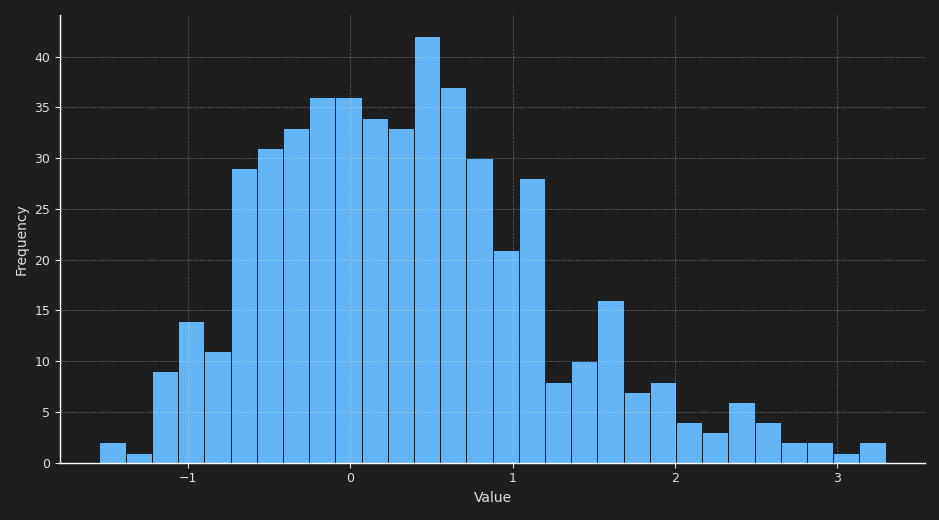

In [3]:
fig, ax = plt.subplots(figsize=FIGSIZE_DEFAULT)
ax.hist(x, bins=30, color=C['blue'], edgecolor='black', linewidth=0.5)
ax.set_xlabel('Value')
ax.set_ylabel('Frequency')
plt.tight_layout()

We can also look at a trace plot of the samples to see how the chain moved around.


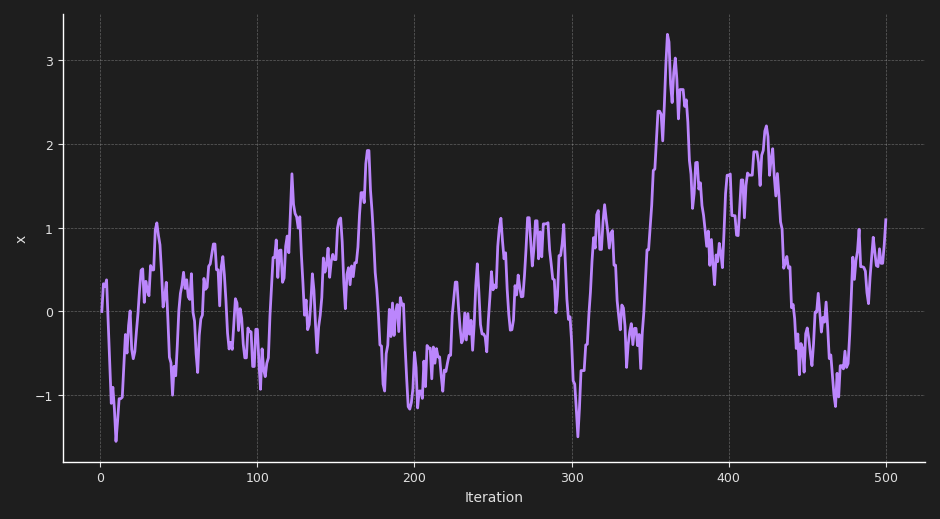

In [4]:
fig, ax = plt.subplots(figsize=FIGSIZE_DEFAULT)
ax.plot(np.arange(1, N+1), x)
ax.set_xlabel('Iteration')
ax.set_ylabel('x')
plt.tight_layout()

What would happen if we changed the value of $\delta$? Here we make $\delta$ bigger and we can see the effect on the trace plot.

In [5]:
delta = 2
N = 500
x = np.zeros(N)
x[0] = 0
rng = np.random.default_rng(20180604)
for i in range(1, N):
    eps = rng.uniform(-delta, delta)
    y = x[i-1] + eps
    alpha = min(stats.norm.logpdf(y) - stats.norm.logpdf(x[i-1]), 0)
    u = rng.uniform(0, 1)
    if np.log(u) <= alpha:
        x[i] = y
    else:
        x[i] = x[i-1]
print(f"Min: {x.min():.2f}, 1st Qu: {np.percentile(x, 25):.2f}, Median: {np.median(x):.2f}, Mean: {x.mean():.2f}, 3rd Qu: {np.percentile(x, 75):.2f}, Max: {x.max():.2f}")

Min: -2.42, 1st Qu: -0.49, Median: 0.17, Mean: 0.25, 3rd Qu: 1.05, Max: 3.39


Now look at the trace plot.

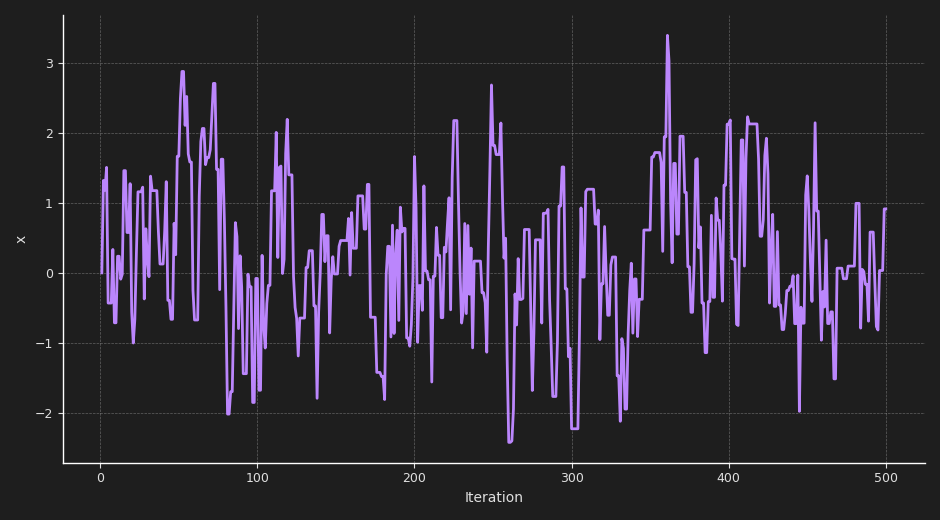

In [6]:
fig, ax = plt.subplots(figsize=FIGSIZE_DEFAULT)
ax.plot(np.arange(1, N+1), x)
ax.set_xlabel('Iteration')
ax.set_ylabel('x')
plt.tight_layout()

You can see in this trace plot that there are a number of iterations where there is no movement (so that the candidate is rejected, whereas in the above trace plot with the smaller value of $\delta$ there was much more movement, although the steps themselves were smaller. In particular, the first chain exhibited a bit more *autocorrelation*. With a larger $\delta$, we are proposing candidates that are much further from the current state, and that may not comport with the Normal distribution. As a result, the candidates are more likely to be rejected.

This raises an important in Markov chain samplers: tuning. The theory does not depend on a specific value of $\delta$; both chains above should converge to a Normal distribution. However, the speed with which they converge and amount of the sample space that is explored does depend on $\delta$. Hence, the sampler can be tuned to improve its efficiency.

### Independence Metropolis Algorithm

The independence Metropolis algorithm defines a transition density as $q(y\mid x) = q(y)$. In other words, the candidate proposals do not depend on the current state x. Otherwise, the algorithm works the same as the original Metropolis-Hastings algorithm, with a modified acceptance ratio,

$$\alpha(y\mid x) = \min\left\{\frac{\pi(y)\,q(x)}{\pi(x)\,q(y)},\,1\right\}$$

The independence sampler seems to work well in situations where rejection sampling might be reasonable, i.e.&nbsp;relatively low-dimensional problems. In particular, it has the interesting property that if

$C=\sup_x \frac{\pi(x)}{q(x)}<\infty$

then

$$\|\pi_n-\pi\| \leq k\rho^n$$

for $0<\rho<1$ and some constant $k>0$. So if we have the same conditions under which rejection sampling is allowed, then we can prove that convergence of the chain to the stationary distribution is geometric with rate $\rho$. The value of $\rho$ depends on $C$; if $C$ is close to $1$, then $\rho$ will be small. This is an interesting property of this sampler, but it is largely of theoretical interest.

### Slice Sampler

Given the current state x, generate

$y\sim\text{Unif}(0,\pi(x))$

Given $y$, generate a new state $x^\star$

$x^\star\sim\text{Unif}(\{x:\pi(x)\geq y\})$

Note that

$$\pi(x) = \int \mathbf{1}\{0\leq y\leq \pi(x)\}\,dy.$$

Therefore, $f(x, y) = \mathbf{1}\{0\leq y\leq\pi(x)\}$ is a joint density. The slice sampler method creates an auxiliary variable $y$ and the intergrates it out later to give back our original target density $\pi(x)$.

As depicted in the illustration, the slice sampler can be useful for densities that might have multiple modes where it's easy to get stuck around one model. The sampling of $x^\star$ allows one to jump easily between modes. However, sampling $x^\star$ may be difficult depending on the complexity of $\pi(x)$ and ultimately may not be worth the effort. If $\pi(x)$ is very wiggly or is high-dimensional, then calculating the region $\{x: \pi(x)\geq y\}$ will be very difficult.

### Hit and Run Sampler

The hit and run sampler combines ideas from line search optimization methods with MCMC sampling. Here, suppose we have the current state $x$ in $p$-dimensions and we want to propose a new state. Let $e$ be a random $p$-dimensional vector that indicates a random direction in which to travel. Then construct the density

$$p(r)\propto \pi(x + r e)$$

where $r$ is a scalar (and hence $p(r)$ is a 1-dimensional density). From this density, sample a value for $r$ and set the proposal to be

$$x^\star = x + r e.$$

This process has the advantage that it chooses more directions than a typical Gibbs sampler (see below) and does not require a multi-dimensional proposal distribution. However, sampling from the density $p(r)$ may not be obvious as there is no guaranteed closed form solution.

### Single Component Metropolis-Hastings

The standard Metropolis algorithm updates the entire parameter vector at once with a single step. Hence, a p-dimensional parameter vector must have a p-dimensional proposal distribution q. However, it is sometimes simpler to update individual components of the parameter vector one at a time, in an algortihm known as single component Metropolis-Hastings (SCMH).

Let $x^{(n)} = (x^{(n)}_1, x^{(n)}_2, \ldots, x^{(n)}_p)$ be a $p$-dimensional vector representing our parameters of interest at iteration n. Define
$x_{-i} = (x_1,\ldots,x_{i-1},x_{i+1},\ldots,x_p)$
as the vector x with the ith component removed. The SCMH algorithm updates each paramater in x one at a time. All that is needed to update the $i$th component of $x^{(n)}$ is a proposal distribution $q(y\mid x_i^{(n)}, x_{-i}^{(n)})$ for proposing a new value of $x_i$ given the current value of $x_i$ and all the other components.

At iteration n, SCMH updates the ith component via the following steps.

1. Sample $y_i\sim q_i(y\mid x_i^{(n)}, x_{-i}^{(n)})$ as a proposal for component $i$.
2. Let $$\alpha(y_i\mid x^{(n)}) = \min\left(\frac{\pi(y_i\mid x_{-i}^{(n)})\,q(x_i\mid y_i,x_{-i}^{(n)})}{\pi(x_i\mid x_{-i}^{(n)})\,q(y_i\mid x_i,x_{-i}^{(n)})}, 1\right)$$
3. Accept $y_i$ for component $i$ with probability $\alpha(y_i\mid x^{(n)})$.
4. Repeat 1–3 $p$ times until every component is updated.